# Learning Quadcopter Dynamics

In this tutorial, we will cover the process of learning a complex dynamical system such as a quadcopter system using SINDy. We will exploit known knowledge of quadcopter dynamics to address several learning challenges by:
1. Careful selection of the candidate function library
2. Designing constraint matrices

In [1]:
# Import all required libraries

import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sindy.plot_utils import init_plt_format

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)
init_plt_format()

# Data Loading

Let us first load in the flight trajectories. Note that in later extractions, we will remove the position states from the data as the dynamics are position-independent. The states will then be
$$
\boldsymbol{x} = \left[ \begin{matrix}
    \phi & \theta & \psi &
    V_x & V_y & V_z &
    p & q & r
\end{matrix} \right]^T.
$$

In [2]:
# Specify log directory and logs
data_dir = 'Tutorials/S2 UAV System ID/data/'
log_names: list[str] = [
    'Step Inputs Processed.npz',
    'Chirp Inputs Processed.npz',
    'Waypoint Pathing Processed.npz'
]

# Load in data
flight_logs: list[dict] = list()
for idx, log_name in enumerate(log_names):

    log = np.load(data_dir + log_name)
    flight_logs.append(log)

    t = log['t']
    duration = t[-1] - t[0]

    print(
        f'Log {idx+1:d} spans {duration:.2f} s and contains {t.shape[0]:d} '
        + 'number of data points.'
    )

# Define the feature and input names
feature_names: list[str] = [
    'phi', 'theta', 'psi',
    'Vx', 'Vy', 'Vz',
    'p', 'q', 'r'
]
input_names: list[str] = ['u1', 'u2', 'u3', 'u4']

Log 1 spans 145.00 s and contains 29001 number of data points.
Log 2 spans 85.00 s and contains 17001 number of data points.
Log 3 spans 85.00 s and contains 17001 number of data points.


## Extract Training Data

We will now extract the step and chirp input logs as our training data.

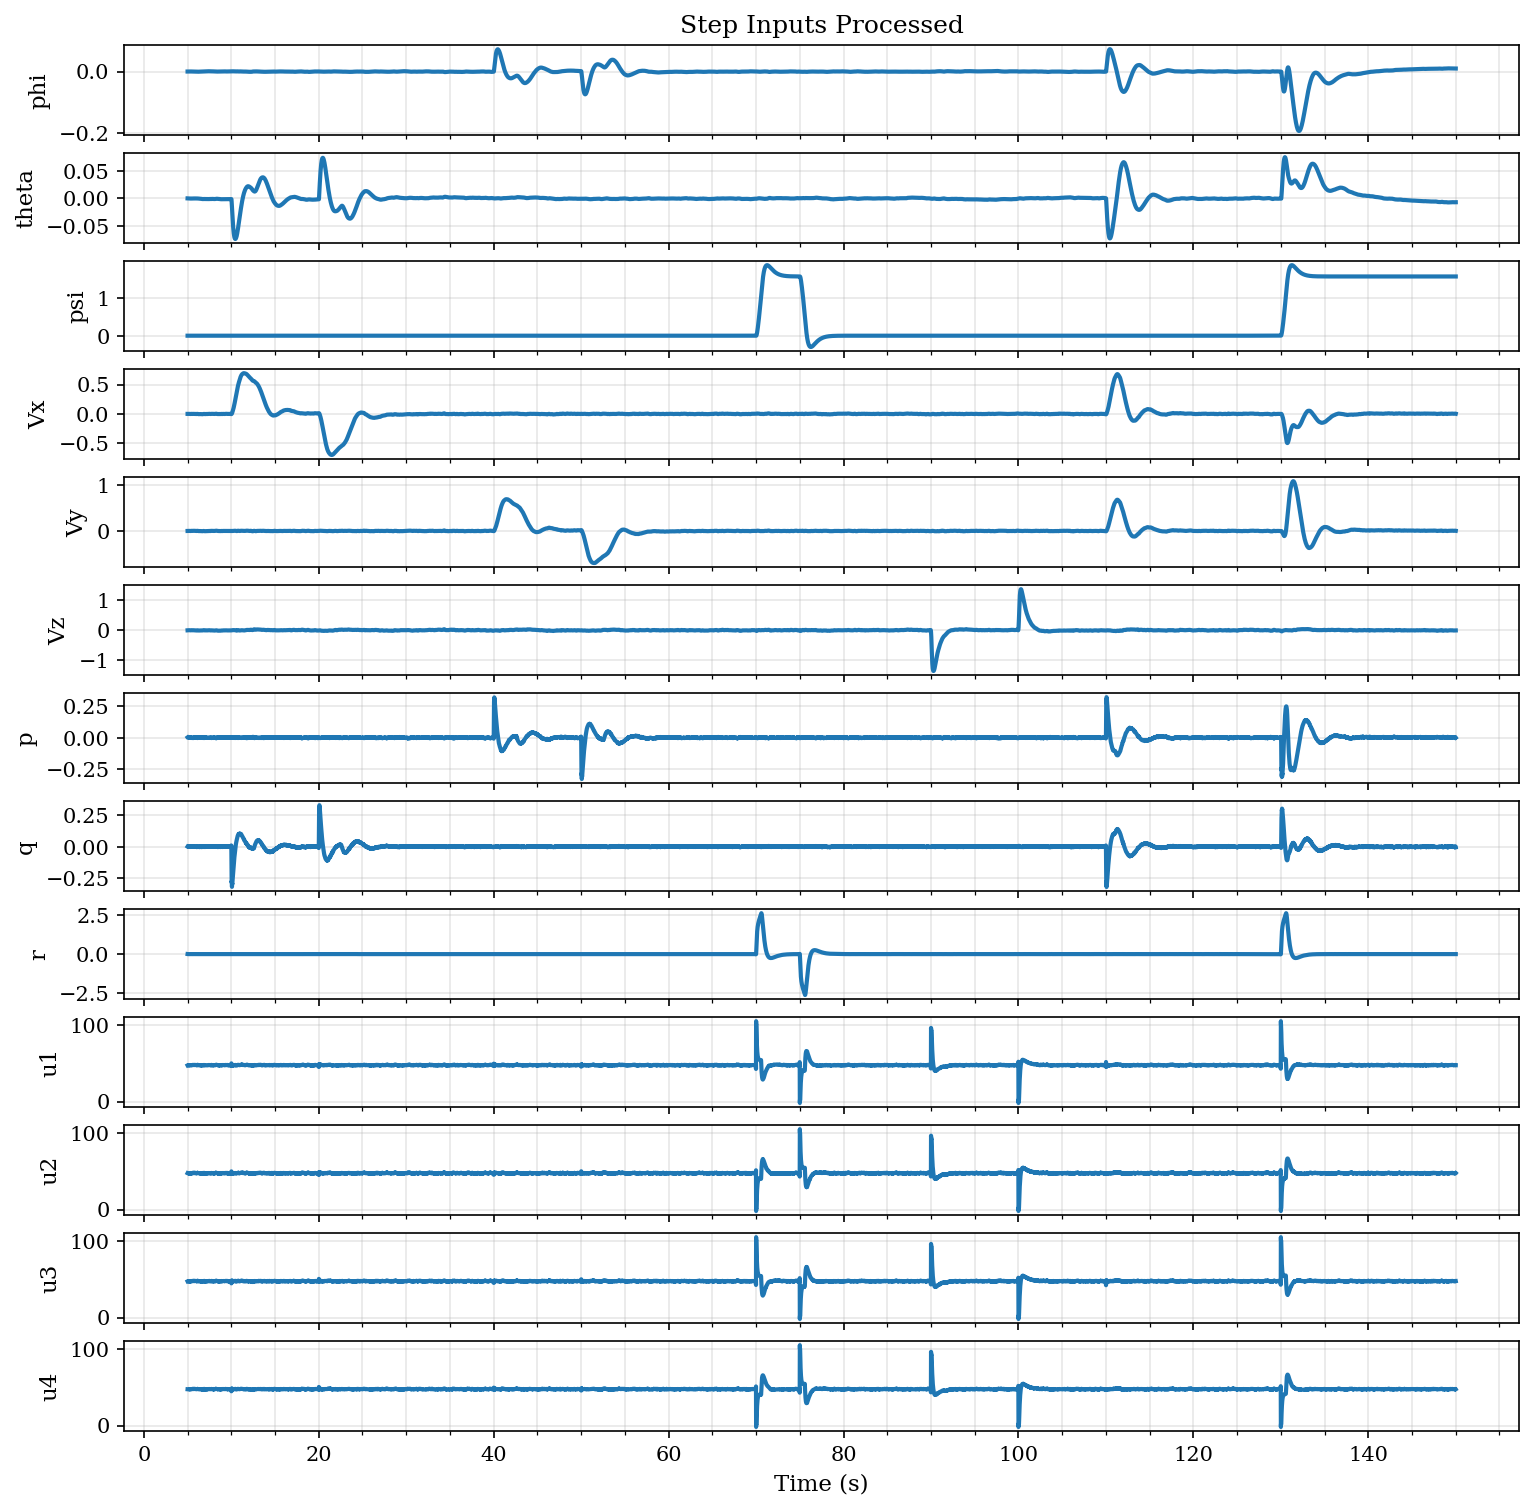

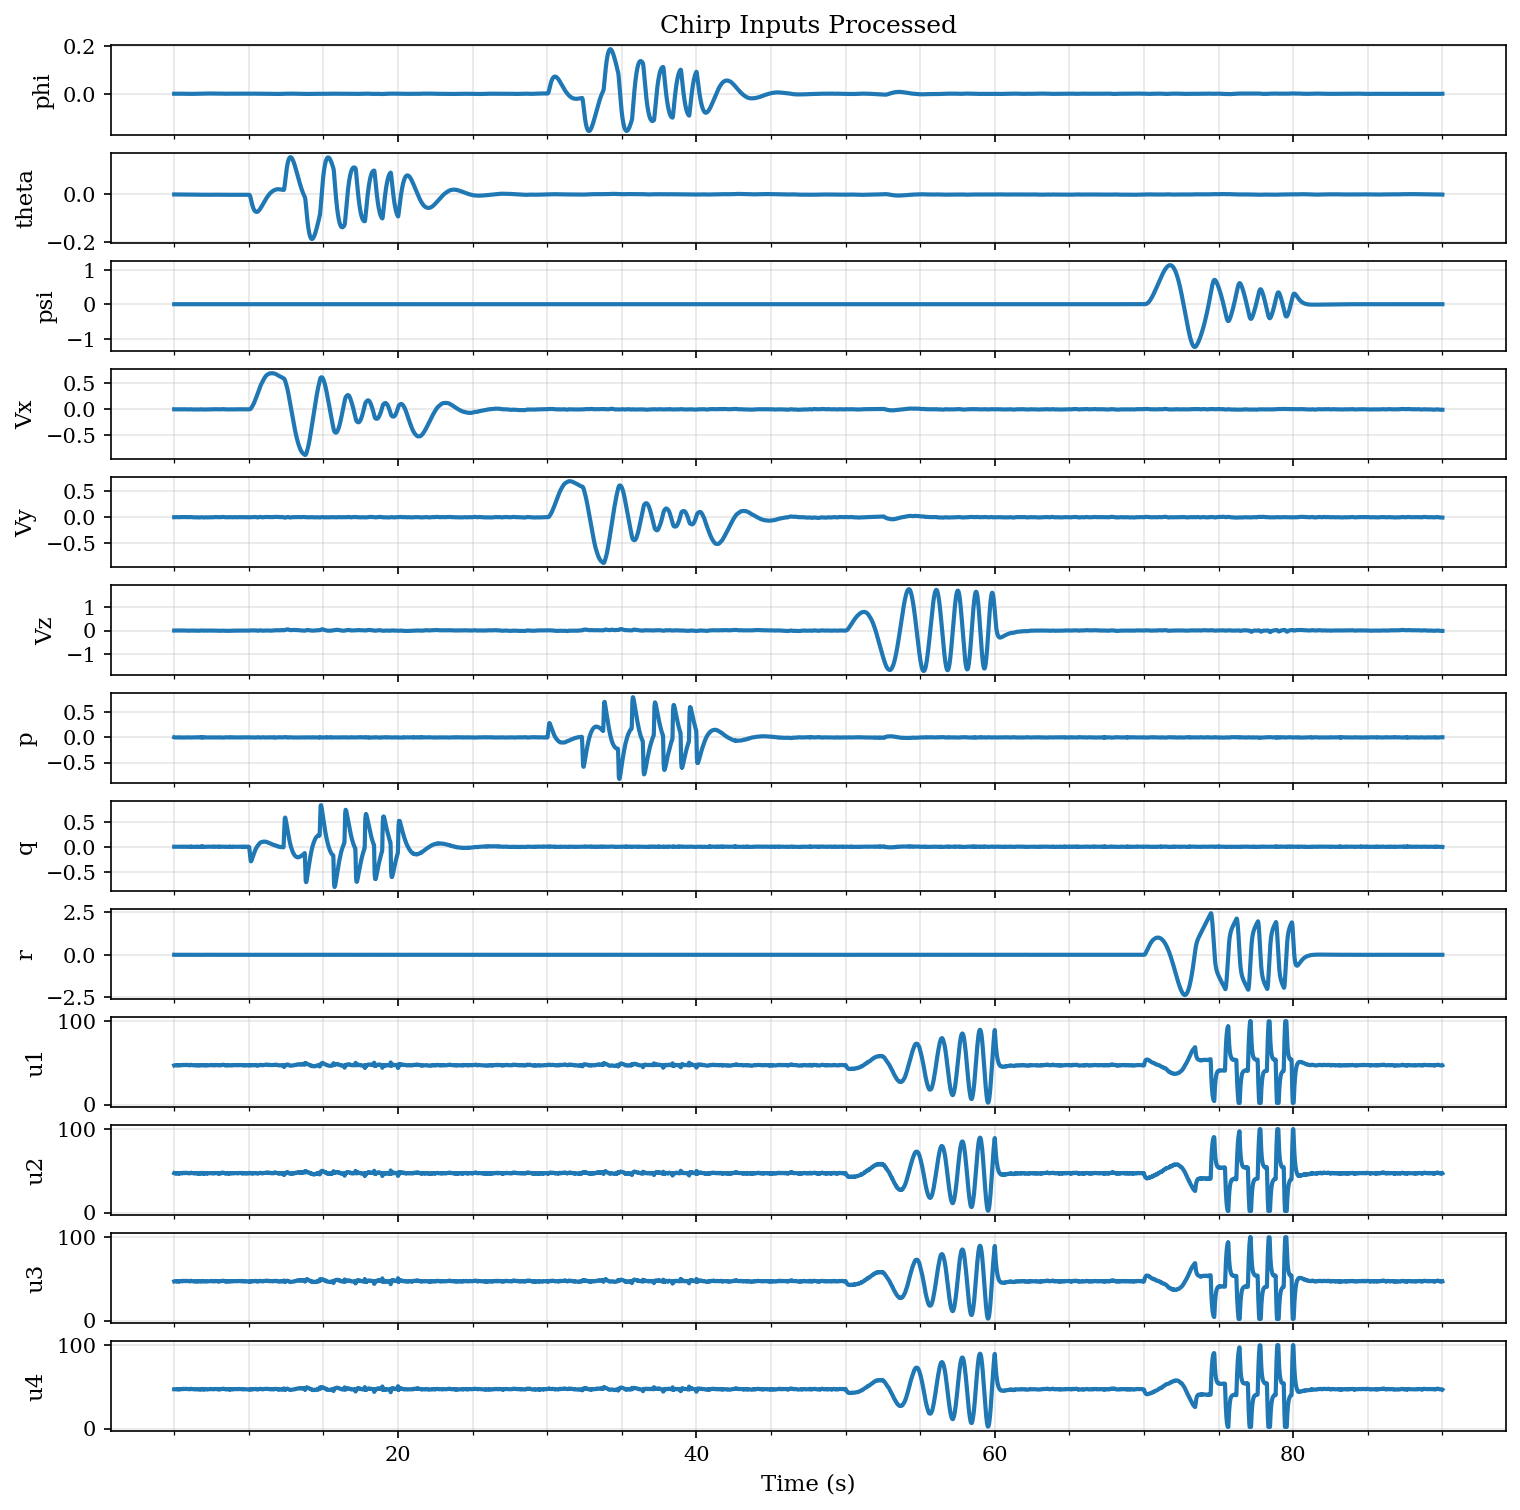

In [48]:
# Define list of logs to be used for training
training_logs = [0, 1]

# Initialise training data
t_train: list[np.ndarray] = list()
x_train: list[np.ndarray] = list()
u_train: list[np.ndarray] = list()

# Extract and plot training data
for log_idx, log in enumerate([flight_logs[idx] for idx in training_logs]):

    # Save training data
    t_train.append(log['t'])
    x_train.append(log['x'][:, 3:])
    u_train.append(log['u'])

    # Visualize training data
    fig, axs = plt.subplots(13, 1, figsize=(12,12), sharex=True)

    for xIdx in range(9):
        axs[xIdx].plot(t_train[-1], log['x'][:, xIdx+3], '-')
        axs[xIdx].set_ylabel(feature_names[xIdx])

    for uIdx in range(4):
        axs[uIdx+9].plot(t_train[-1], u_train[-1][:, uIdx])
        axs[uIdx+9].set_ylabel(input_names[uIdx])
        
    axs[-1].set_xlabel('Time (s)')
    axs[0].set_title(log_names[training_logs[log_idx]].removesuffix('.npz'))

## Extract Validation Data

We will use the flight log with a sample 3 waypoint flight plan as the validation data.

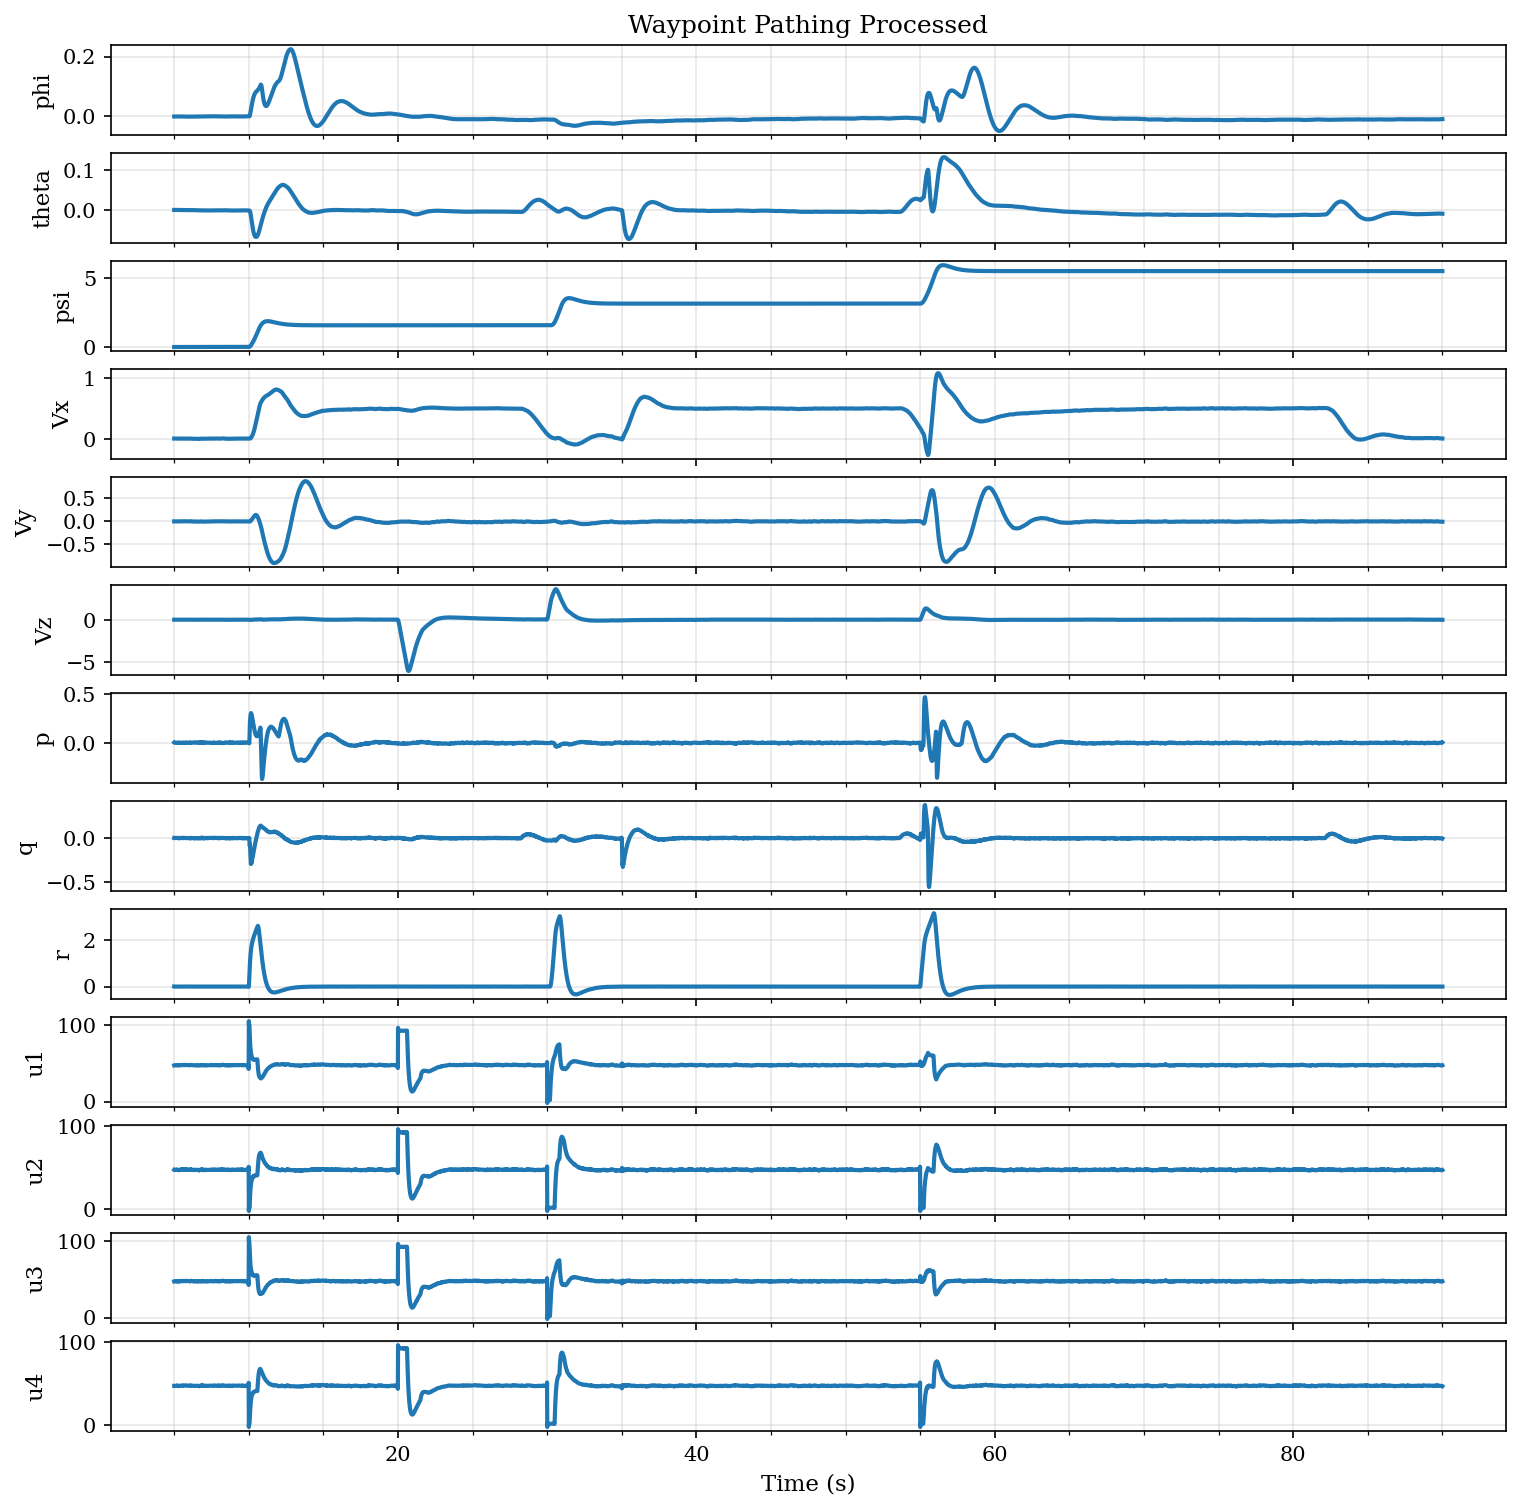

In [49]:
# Define list of logs to be used for validation
validation_logs = [2]

# Initialise validation data
t_valid: list[np.ndarray] = list()
x_valid: list[np.ndarray] = list()
u_valid: list[np.ndarray] = list()

# Extract validation data
for log_idx, log in enumerate([flight_logs[idx] for idx in validation_logs]):

    # Save validation data
    t_valid.append(log['t'])
    x_valid.append(log['x'][:, 3:])
    u_valid.append(log['u'])

    # Visualize validation data
    fig, axs = plt.subplots(13, 1, figsize=(12,12), sharex=True)

    for xIdx in range(9):
        axs[xIdx].plot(t_valid[-1], log['x'][:, xIdx+3])
        axs[xIdx].set_ylabel(feature_names[xIdx])

    for uIdx in range(4):
        axs[uIdx+9].plot(t_valid[-1], u_valid[-1][:, uIdx])
        axs[uIdx+9].set_ylabel(input_names[uIdx])
    axs[-1].set_xlabel('Time (s)')
    axs[0].set_title(log_names[validation_logs[log_idx]].removesuffix('.npz'))

# Embedding Prior Knowledge

Recall that the quadcopter dynamics are governed by

$$
\begin{aligned}
    \dot{\phi} &= p + \tan(\theta) \left[ q \sin(\theta) + r \cos(\phi) \right], \\
    \dot{\theta} &= q \cos(\phi) - r \sin(\phi), \\
    \dot{\psi} &= \sec(\theta) \left[ q \sin(\theta) + r \cos(\phi) \right], \\
    \dot{v}_x &= (r v_y - q v_z) - g \sin(\theta) + F_x / m, \\
    \dot{v}_y &= (p v_z - r v_x) + g \cos(\theta) \sin(\phi) + F_y / m, \\
    \dot{v}_z &= (q v_x - p v_y) + g \cos(\phi) \cos(\theta) + F_z / m, \\
    \dot{p} &= \left[ M_x + qr(I_{yy} - I_{zz}) \right] / I_{xx}, \\
    \dot{q} &= \left[ M_y + pr(I_{zz} - I_{xx}) \right] / I_{yy}, \\
    \dot{r} &= \left[ M_z + pq(I_{xx} - I_{yy}) \right] / I_{zz}. \\
\end{aligned}
$$

Within this set of equations derived from principles of mechanics, many terms whilst complex are known. For example, the time derivatives of the Euler angles are simply the angular body rates with an applied rotation matrix. There are also terms where we know the exact coefficients as well such as the gravitational acceleration $g$. The true unknown terms are the resultant forces $F$ and moments $M$ acting on the vehicle due to motor commands or external forces such as drag.

In this section, we will methodically construct a candidate function library and impose the appropriate coefficient constraints that reflect the physics.


## Designing the Candidate Function Library

Usually in SINDy, we build our candidate function libraries using a function basis such as polynomials or Fourier. However, we may also build it directly with tailored terms using PySINDy's `CustomLibrary`. In addition to specifying the function, we may also designate which states/inputs should be fed into the specified function using the function argument `inputs_per_library` of the `GeneralizedLibrary` class. The variable `inputs_per_library` should be a double-nested list of indices, where the outer list corresponds to a `CustomLibrary` instance. The inner list then specifies the states to be used for that library.

Let us initialize a few useful variables first.

In [50]:
# Obtain data dimensions
m = x_train[0].shape[0]
n = x_train[0].shape[1]
q = u_train[0].shape[1]

### Euler Angles

Here, let us build an Euler angle functions which applies the rotation transformation on the angular body rates. These functions should only accept $\phi$, $\theta$, $p$, $q$ and $r$ as inputs.

In [51]:
# Define Euler attitude angle library
eu_ang_func = [
    lambda phi, theta, p, q, r: p + np.tan(theta) * (q*np.sin(phi) + r*np.cos(phi)),
    lambda phi, theta, p, q, r: q*np.cos(phi) - r*np.sin(phi),
    lambda phi, theta, p, q, r: (q*np.sin(phi)+r*np.cos(phi))/np.cos(theta)
]
eu_ang_names = [
    lambda phi, theta, p, q, r: f'({p} + tan({theta}) * ({q}*sin({phi}) + {r}*cos({phi})))',
    lambda phi, theta, p, q, r: f'({q}*cos({phi}) - {r}*sin({phi}))',
    lambda phi, theta, p, q, r: f'({q}*sin({phi})+{r}*cos({phi}))/cos({theta})'
]
eu_ang_lib = ps.CustomLibrary(eu_ang_func, eu_ang_names)

# Limit the Euler angle libraries to only the relevant states
eu_ang_inputs = [0, 1, 6, 7, 8]

### Gravitational Acceleration Terms

Within the global frame of reference, gravity acts directly downwards. However, within the local rotating frame of reference, another rotation transformation must be applied to determine the direction of the gravity vector. These functions should only accept $\phi$ and $\theta$ as inputs.

In [52]:
# Define the z axis rotational matrix library
grav_func = [
    lambda phi, theta: -np.sin(theta),
    lambda phi, theta: np.cos(theta) * np.sin(phi),
    lambda phi, theta: np.cos(phi) * np.cos(theta)
]
grav_names = [
    lambda phi, theta: f'-sin({theta})',
    lambda phi, theta: f'cos({theta}) * sin({phi})',
    lambda phi, theta: f'cos({phi}) * cos({theta})'
]
grav_lib = ps.CustomLibrary(grav_func, grav_names)

# Limit the z axis rotational matix to relevant states
grav_inputs = [0, 1]

### Angular Rate Cross Product Terms

The angular rate cross coupling terms seen in the time derivatives of $p$, $q$ and $r$ are a result of a self cross product of $[p, q, r]^T$. This library should only accept the states $p$, $q$ and $r$. Note that we have assumed that the quadcopter has symmetrical properties along all three principal axes planes such that the cross products of inertia ($I_{xy}$, $I_{xz}$ and $I_{yz}$) are removed from the equation.

In [53]:
# Define the angular rate cross coupling library
rateCP_func = [
    lambda p, q, r: q*r,
    lambda p, q, r: p*r,
    lambda p, q, r: p*q
]
rateCP_names = [
    lambda p, q, r: f'{q}*{r}',
    lambda p, q, r: f'{p}*{r}',
    lambda p, q, r: f'{p}*{q}'
]
rateCP_lib = ps.CustomLibrary(rateCP_func, rateCP_names)

# Limit the angular rate cross coupling to relevant states
rateCP_inputs = [6, 7, 8]

### Linear and Angular Velocity Cross Product Terms

In the time derivatives of $v_x$, $v_y$ and $v_z$, there are cross coupling terms that arise from a cross product between $[p, q, r]^T$ and $[v_x, v_y, v_z]^T$.This function should only accept the 6 states involved in the cross product.

In [54]:
# Define coriolis library
velOmegaCP_func = [
    lambda u, v, w, p, q, r: r*v - q*w,
    lambda u, v, w, p, q, r: p*w - r*u,
    lambda u, v, w, p, q, r: q*u - p*v
]
velOmegaCP_names = [
    lambda u, v, w, p, q, r: f'({r}*{v} - {q}*{w})',
    lambda u, v, w, p, q, r: f'({p}*{w} - {r}*{u})',
    lambda u, v, w, p, q, r: f'({q}*{u} - {p}*{v})'
]
velOmegaCC_lib = ps.CustomLibrary(velOmegaCP_func, velOmegaCP_names)

# Limit coriolis to relevant states
velOmegaCP_inputs = [3, 4, 5, 6, 7, 8]

### Drag Terms

Aerodynamic forces are proportional to the square of the freestream velocity. Hence, we will introduce a quadratic library for the three linear velocity terms.

In [55]:
# Define quadratic library
drag_func = [lambda u: u**2]
drag_names = [lambda u: f'{u}^2']
drag_lib = ps.CustomLibrary(drag_func, drag_names)

# Limit the quadratic library to only the controls input
drag_inputs = [3, 4, 5]

### Angular Rate Damping Terms

At high pitching and rolling rates, opposing propeller discs observe different angles of attack and will produce different thrust forces. This results in a form of aerodynamic damping as a result of pitch and roll, as outlined in [(Pounds et al, 2006)](https://openresearch-repository.anu.edu.au/items/d053d123-3099-4969-bd9c-185fa3412018). We will restrict this library to only accept $p$ and $q$ as inputs.

In [56]:
# Define quadratic library
damp_func = [lambda u: u]
damp_names = [lambda u: f'{u}']
damp_lib = ps.CustomLibrary(damp_func, damp_names)

# Limit the angular rate damping to only p and q
damp_inputs = [6, 7]

### Control Input Terms

Last but not least, we have the unknown propeller force and moment generation as a function of the motor inputs. We will apply a polynomial basis function library. Note that we will disable cross-coupled terms as we assume that the forces and moments generated from each propeller disc is independent from one another.

In [57]:
# Define controls polynomial library parameters
poly_order: int = 3
include_bias: bool = False

# Define polynomial library
cont_lib = ps.PolynomialLibrary(
    poly_order, include_bias=include_bias, include_interaction=False
)

# Limit the polynomial library to only the controls input
cont_inputs = list()
for idx in range(n, n+q):
    cont_inputs.append(idx)

### Assembling the Library

Now that we have defined the individual components of the function library, we can concatenate it all together into a `GeneralizedLibrary`. Note that the order of the list of libraries provided must match the order of corresponding libraries in `inputs_per_library`.

In [58]:
lib = ps.GeneralizedLibrary(
    libraries=[
        eu_ang_lib, grav_lib, rateCP_lib, velOmegaCC_lib,
        drag_lib, damp_lib, cont_lib
    ],
    inputs_per_library=[
        eu_ang_inputs, grav_inputs, rateCP_inputs, velOmegaCP_inputs,
        drag_inputs, damp_inputs, cont_inputs
    ]
)

# Create a dummy fitted model to extract library terms
model = ps.SINDy(feature_library=lib)
model.fit(x_train, t_train, u=u_train, feature_names=feature_names+input_names)

# Print library terms
library_names = model.get_feature_names()
for idx, name in enumerate(library_names):
    print(f'{idx:d} : {name}')

# Extract total library size
l: int = len(library_names)

0 : (p + tan(theta) * (q*sin(phi) + r*cos(phi)))
1 : (q*cos(phi) - r*sin(phi))
2 : (q*sin(phi)+r*cos(phi))/cos(theta)
3 : -sin(theta)
4 : cos(theta) * sin(phi)
5 : cos(phi) * cos(theta)
6 : q*r
7 : p*r
8 : p*q
9 : (r*Vy - q*Vz)
10 : (p*Vz - r*Vx)
11 : (q*Vx - p*Vy)
12 : Vx^2
13 : Vy^2
14 : Vz^2
15 : p
16 : q
17 : u1
18 : u2
19 : u3
20 : u4
21 : u1^2
22 : u2^2
23 : u3^2
24 : u4^2
25 : u1^3
26 : u2^3
27 : u3^3
28 : u4^3


## Designing Constraint Matrices

We know the exact coefficients of some of the functions within the library, or we know exactly where they should be appear in the equation structure. Knowing this, we can specify our constraints accordingly.

### Enforcing Known Coefficients

For functions such as gravitational forcing, we know its exact coefficient value of $g$. And for others such as the cross vector product between linear velocities and angular velocities, we know its coefficient should be exactly one. In the code below, we create constraints for the library terms specified in `lib_idx` for each `state_idx`, with a RHS value that should equal to the corresponding element in `rhs_values`.

In [59]:
# Known gravitational acceleration
g: float = 9.81

# Define the library terms to enforce sparsification and constrain coefficients
lib_idx = [
    0, 1, 2, # Euler angle constraints
    3, 4, 5, # Gravitational acceleration constraints
    9, 10, 11, # Linear and angular velocity cross products
]

# Define the states the terms should be applied to
state_idx = [
    0, 1, 2, # Euler angle constraints
    3, 4, 5, # Gravitational acceleration constants
    3, 4, 5 # Linear and angular velocity cross products
]

# Define the RHS values
rhs_values = [
    1.0, 1.0, 1.0,
    g, g, g,
    1.0, 1.0, 1.0,
]

# Initialise constraint matrices
n_constraints = len(lib_idx)*n
known_coef_lhs = np.zeros((n_constraints, l*n))
known_coef_rhs = np.zeros((n_constraints,))

# Enforce known coefficients
for f_idx in range(len(lib_idx)):
    for s_idx in range(n):
        idx = f_idx*n + s_idx
        known_coef_lhs[idx, lib_idx[f_idx]*n + s_idx] = 1.0
        if s_idx == state_idx[f_idx]:
            known_coef_rhs[idx] = rhs_values[f_idx]
        else:
            known_coef_rhs[idx] = 0.0

### Enforcing Known Sparsity

There are also certain functions that we do not know the coefficients of, but we know where it should and should not exist within the equation. In the code below, for each function specified in `lib_idx`, we specify where it should be forcefully sparsified to zero in `state_idx`.

In [60]:
# Specify the index at which control inputs appear in the library
control_idx: int = 17

# Define the library terms to enforce sparsity on
lib_idx = [
    6, 7, 8, # Angular rate cross product terms
    12, 13, 14, # Velocity terms for drag
    15, 16, # Angular rate damping
] + list(range(control_idx, l)) # Control inputs

# Define the target states to exclude for each element in lib_idx
state_idx = [
    list(range(6)) + [7, 8],
    list(range(6)) + [6, 8],
    list(range(6)) + [6, 7],
    list(range(3)) + list(range(4, 9)),
    list(range(4)) + list(range(5, 9)),
    list(range(5)) + list(range(6, 9)),
    list(range(6)) + list(range(7, 9)),
    list(range(7)) + list(range(8, 9)),
] + [list(range(5)) for _ in range(l-control_idx)]

# Initialise constraint matrices
n_constraints = sum(len(t_idx) for t_idx in state_idx)
known_sparsity_lhs = np.zeros((n_constraints, l*n))
known_sparsity_rhs = np.zeros((n_constraints,))

# Enforce known sparsity constraints
constraint_idx = 0
for idx, l_idx in enumerate(lib_idx):
    for s_idx in state_idx[idx]:
        known_sparsity_lhs[constraint_idx, l_idx*n + s_idx] = 1.0
        constraint_idx += 1

### Enforcing Control Symmetry

Given that the Parrot Minidrone has its motors separated by equal distance and equal angles from its centre of mass, we can assume control symmetry. For instance, rolling moments should be created by equal and opposite inputs from left and right motors. This significantly aids in the process of disambiguating similar forces/moments generated by pairs of motor inputs. However, if the motors are not of equal distance and equal angle from one another, then `symmetry_configs` should be adjusted accordingly.

In [61]:
# Specify a list of symmetric configurations, where the first element of each
# tuple contains the state to specify followed by the ratio of input commands
# for that state
symmetry_configs = [
    (5, [1, 1, 1, 1]),   # Thrust constraints
    (6, [1, -1, -1, 1]), # Roll constraints
    (7, [1, 1, -1, -1]), # Pitch constraints
    (8, [1, -1, 1, -1])  # Yaw constraints
]

# Initialise constraint matrices
n_constraints = poly_order * (q-1) * len(symmetry_configs)
control_sym_lhs = np.zeros((n_constraints, l*n))
control_sym_rhs = np.zeros((n_constraints,))
constraint_idx = 0

# Specify constraints
for state_idx, rotor_dir in symmetry_configs:
    for poly_idx in range(poly_order):
        for q_idx in range(1, q):
            control_sym_lhs[
                constraint_idx,
                (poly_idx*q+control_idx)*n + state_idx
            ] = -rotor_dir[0]
            control_sym_lhs[
                constraint_idx,
                (poly_idx*q+q_idx+control_idx)*n + state_idx
            ] = rotor_dir[q_idx]
            constraint_idx += 1

### Assemble the Constraint Matrices

Now let us assemble the constraint matrices that can be passed into PySINDy.

In [62]:
# -------------------- Combine final constraint matrices -------------------- #

constraint_lhs = np.concatenate(
    [known_coef_lhs, known_sparsity_lhs, control_sym_lhs], axis=0
)
constraint_rhs = np.concatenate(
    [known_coef_rhs, known_sparsity_rhs, control_sym_rhs], axis=0
)

print(
    f'Created a total of {constraint_rhs.shape[0]:d} constraints for a '
    + f'library size of {constraint_lhs.shape[1]:d}.'
)

Created a total of 241 constraints for a library size of 261.


As we can see above, despite having a tremendously large library, with the right physics-informed constraints, we can still yield a relatively sparse and accurate model.


# Sparse Regression

In PySINDy, constrained regression is only supported by SR3 (sparse relax regularized regression) method by [(Champion et al, 2020)](https://ieeexplore.ieee.org/abstract/document/9194760/) and [(Zheng et al, 2018)](https://ieeexplore.ieee.org/abstract/document/8573778). We may compute an equivalent L0 regularization weight using `ConstrainedSR3.calculate_l0_weight` as STLSQ. It also offer other features such as trimming of corrupt data as well as a native implementation of weighted thresholding.

In [73]:
nu = 1.0
thresholds = np.array([
    0.1, 0.1, 0.1, # Euler angles
    0.01, 0.01, 0.01, # Linear velocities
    0.001, 0.001, 0.001, # Angular velocities
])

for idx in range(len(thresholds)):
    thresholds[idx] = ps.ConstrainedSR3.calculate_l0_weight(thresholds[idx], nu)

opti = ps.ConstrainedSR3(
    np.repeat(thresholds[:, None], l, axis=1), 'weighted_l0', nu,
    constraint_lhs=constraint_lhs, constraint_rhs=constraint_rhs,
    equality_constraints=True, constraint_order='feature',
    trimming_fraction=0.1, max_iter=100, tol=1e-1
)
diff = ps.FiniteDifference(order=6)
model = ps.SINDy(opti, lib, diff)
model.fit(x_train, t_train, u=u_train, feature_names=feature_names+input_names)

model.print(precision=3)

(phi)' = 1.000 (p + tan(theta) * (q*sin(phi) + r*cos(phi)))
(theta)' = 1.000 (q*cos(phi) - r*sin(phi))
(psi)' = 1.000 (q*sin(phi)+r*cos(phi))/cos(theta)
(Vx)' = 9.810 -sin(theta) + 1.000 (r*Vy - q*Vz)
(Vy)' = 9.810 cos(theta) * sin(phi) + 1.000 (p*Vz - r*Vx) + 0.010 Vy^2
(Vz)' = 9.810 cos(phi) * cos(theta) + 1.000 (q*Vx - p*Vy) + -0.051 u1 + -0.051 u2 + -0.051 u3 + -0.051 u4
(p)' = 1.666 q*r + -1.991 p + -0.200 u1 + 0.200 u2 + 0.200 u3 + -0.200 u4 + 0.002 u1^2 + -0.002 u2^2 + -0.002 u3^2 + 0.002 u4^2
(q)' = 0.744 p*r + -2.089 q + 0.147 u1 + 0.147 u2 + -0.147 u3 + -0.147 u4 + -0.002 u1^2 + -0.002 u2^2 + 0.002 u3^2 + 0.002 u4^2
(r)' = 0.448 p*q + 0.283 u1 + -0.283 u2 + 0.283 u3 + -0.283 u4 + -0.002 u1^2 + 0.002 u2^2 + -0.002 u3^2 + 0.002 u4^2


## Assessing Accuracy using Training Data

Let us first assess the accuracy of the model against the training data.

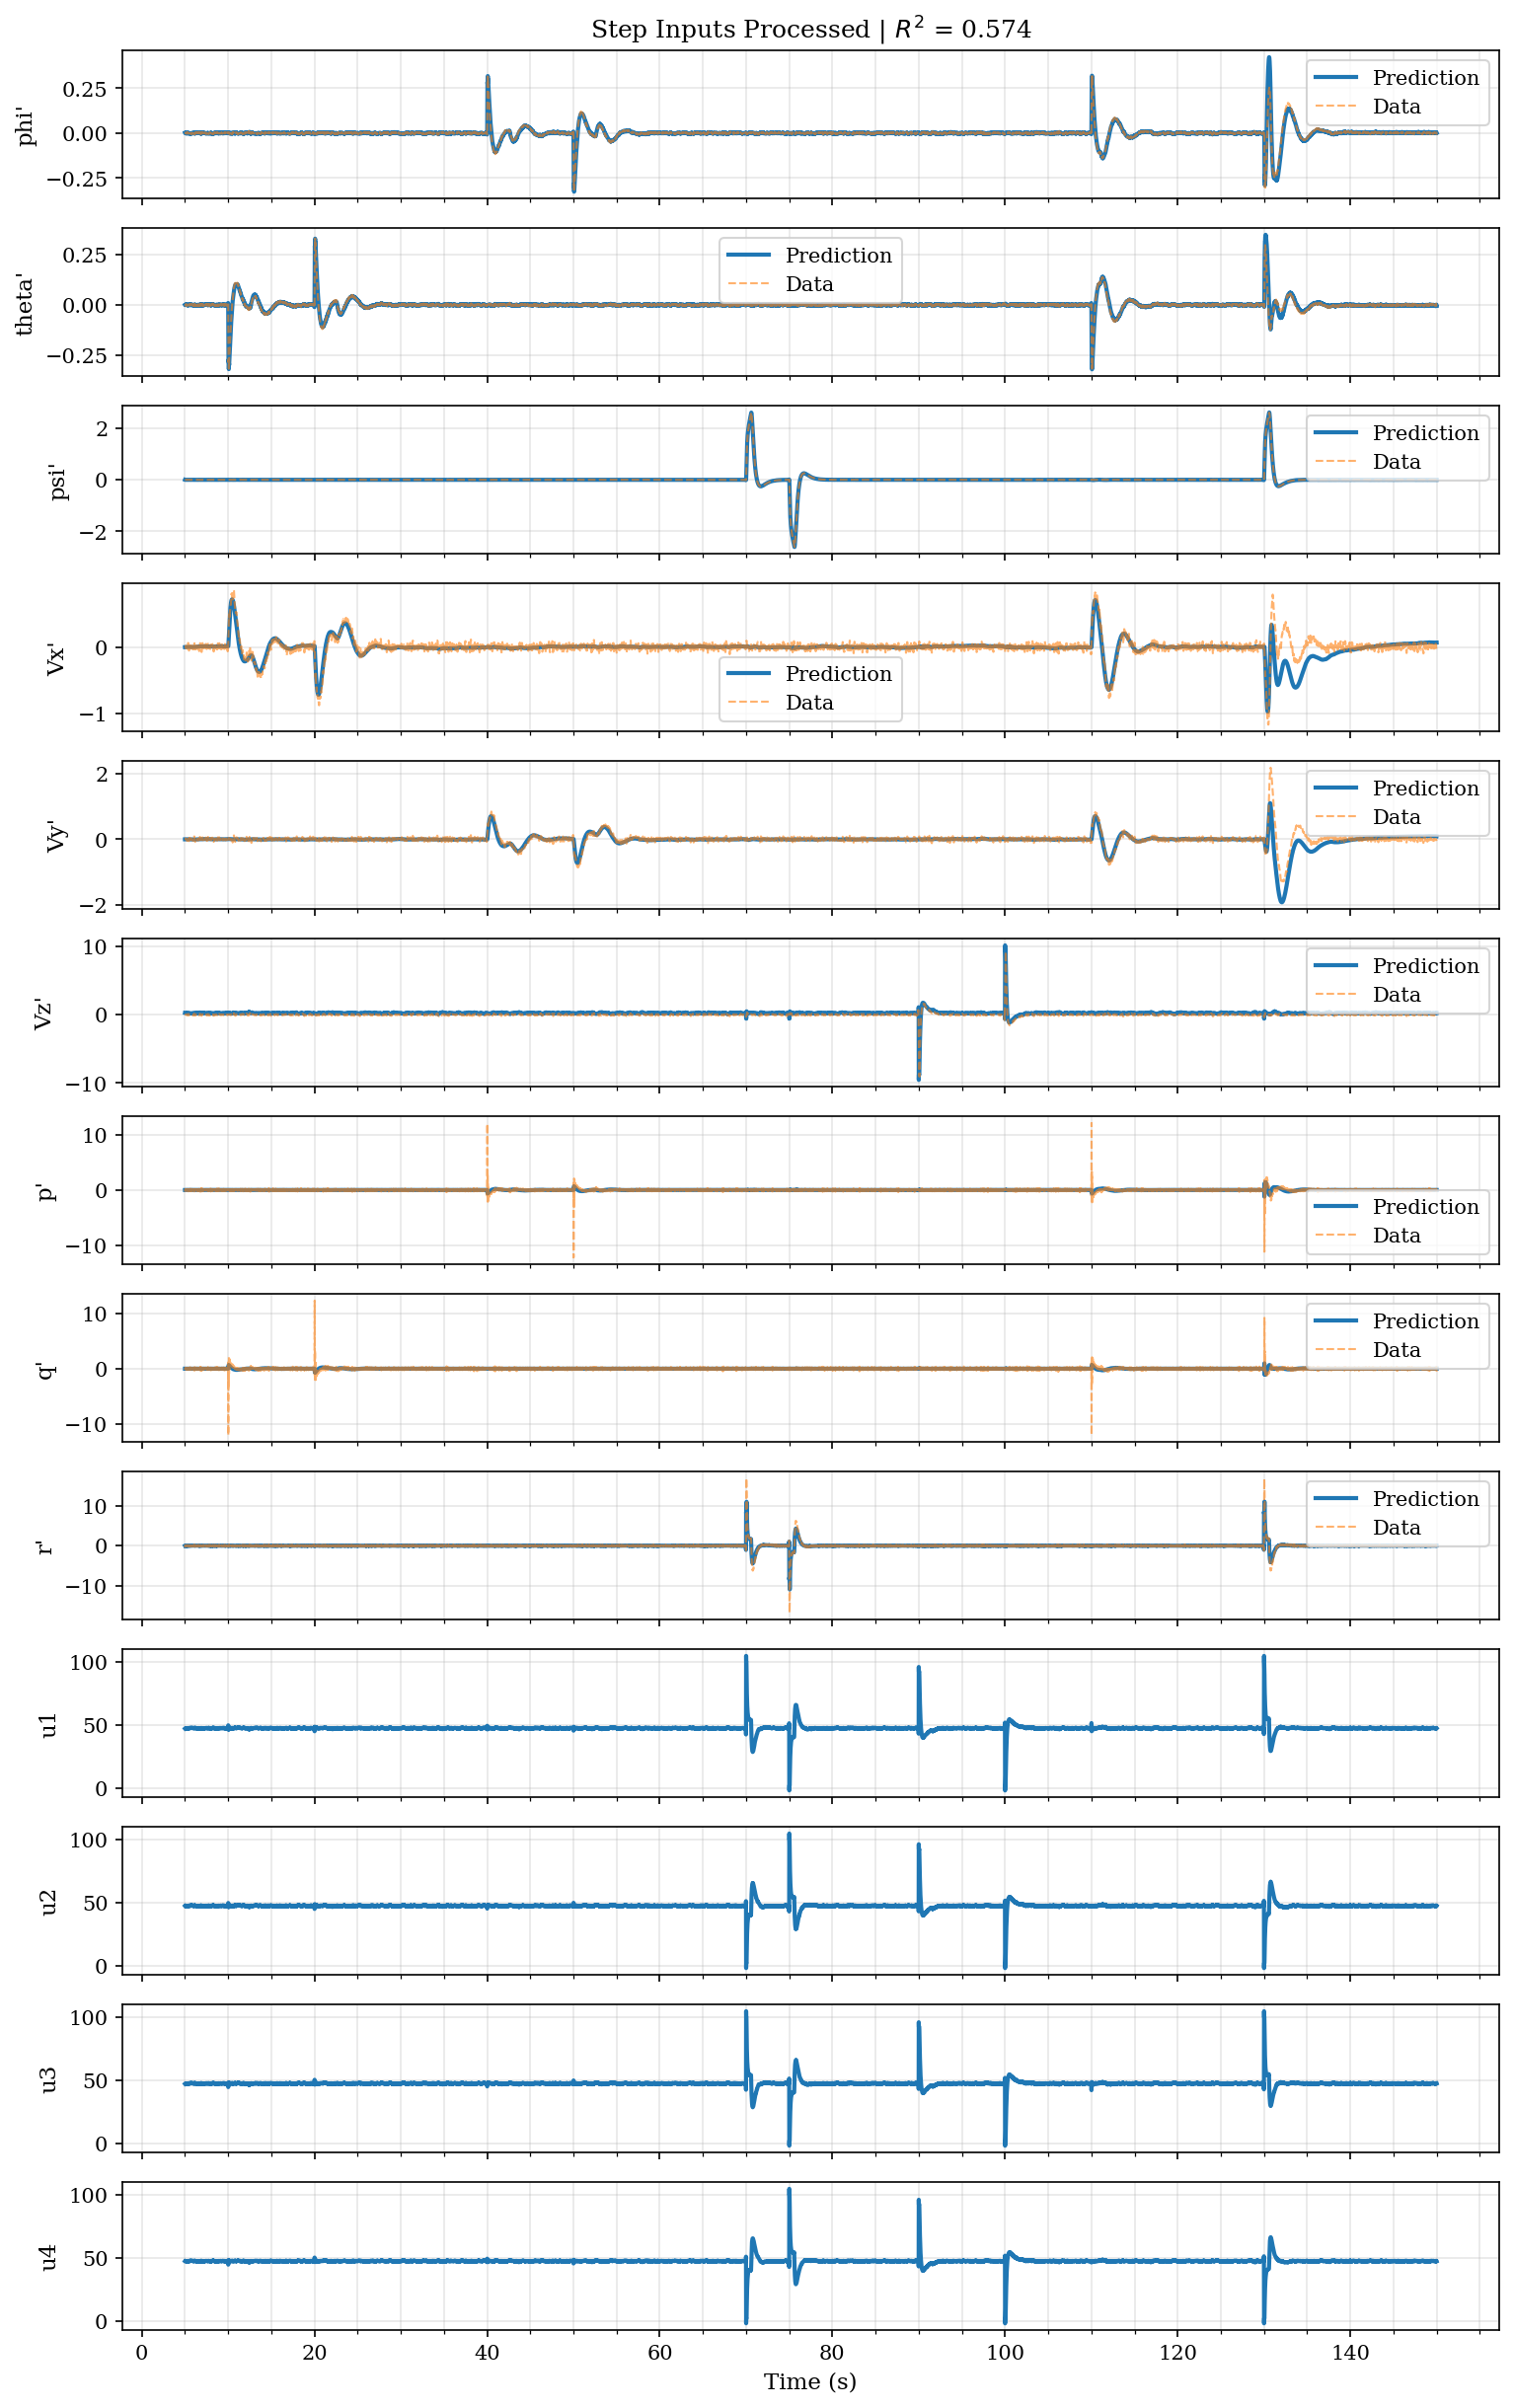

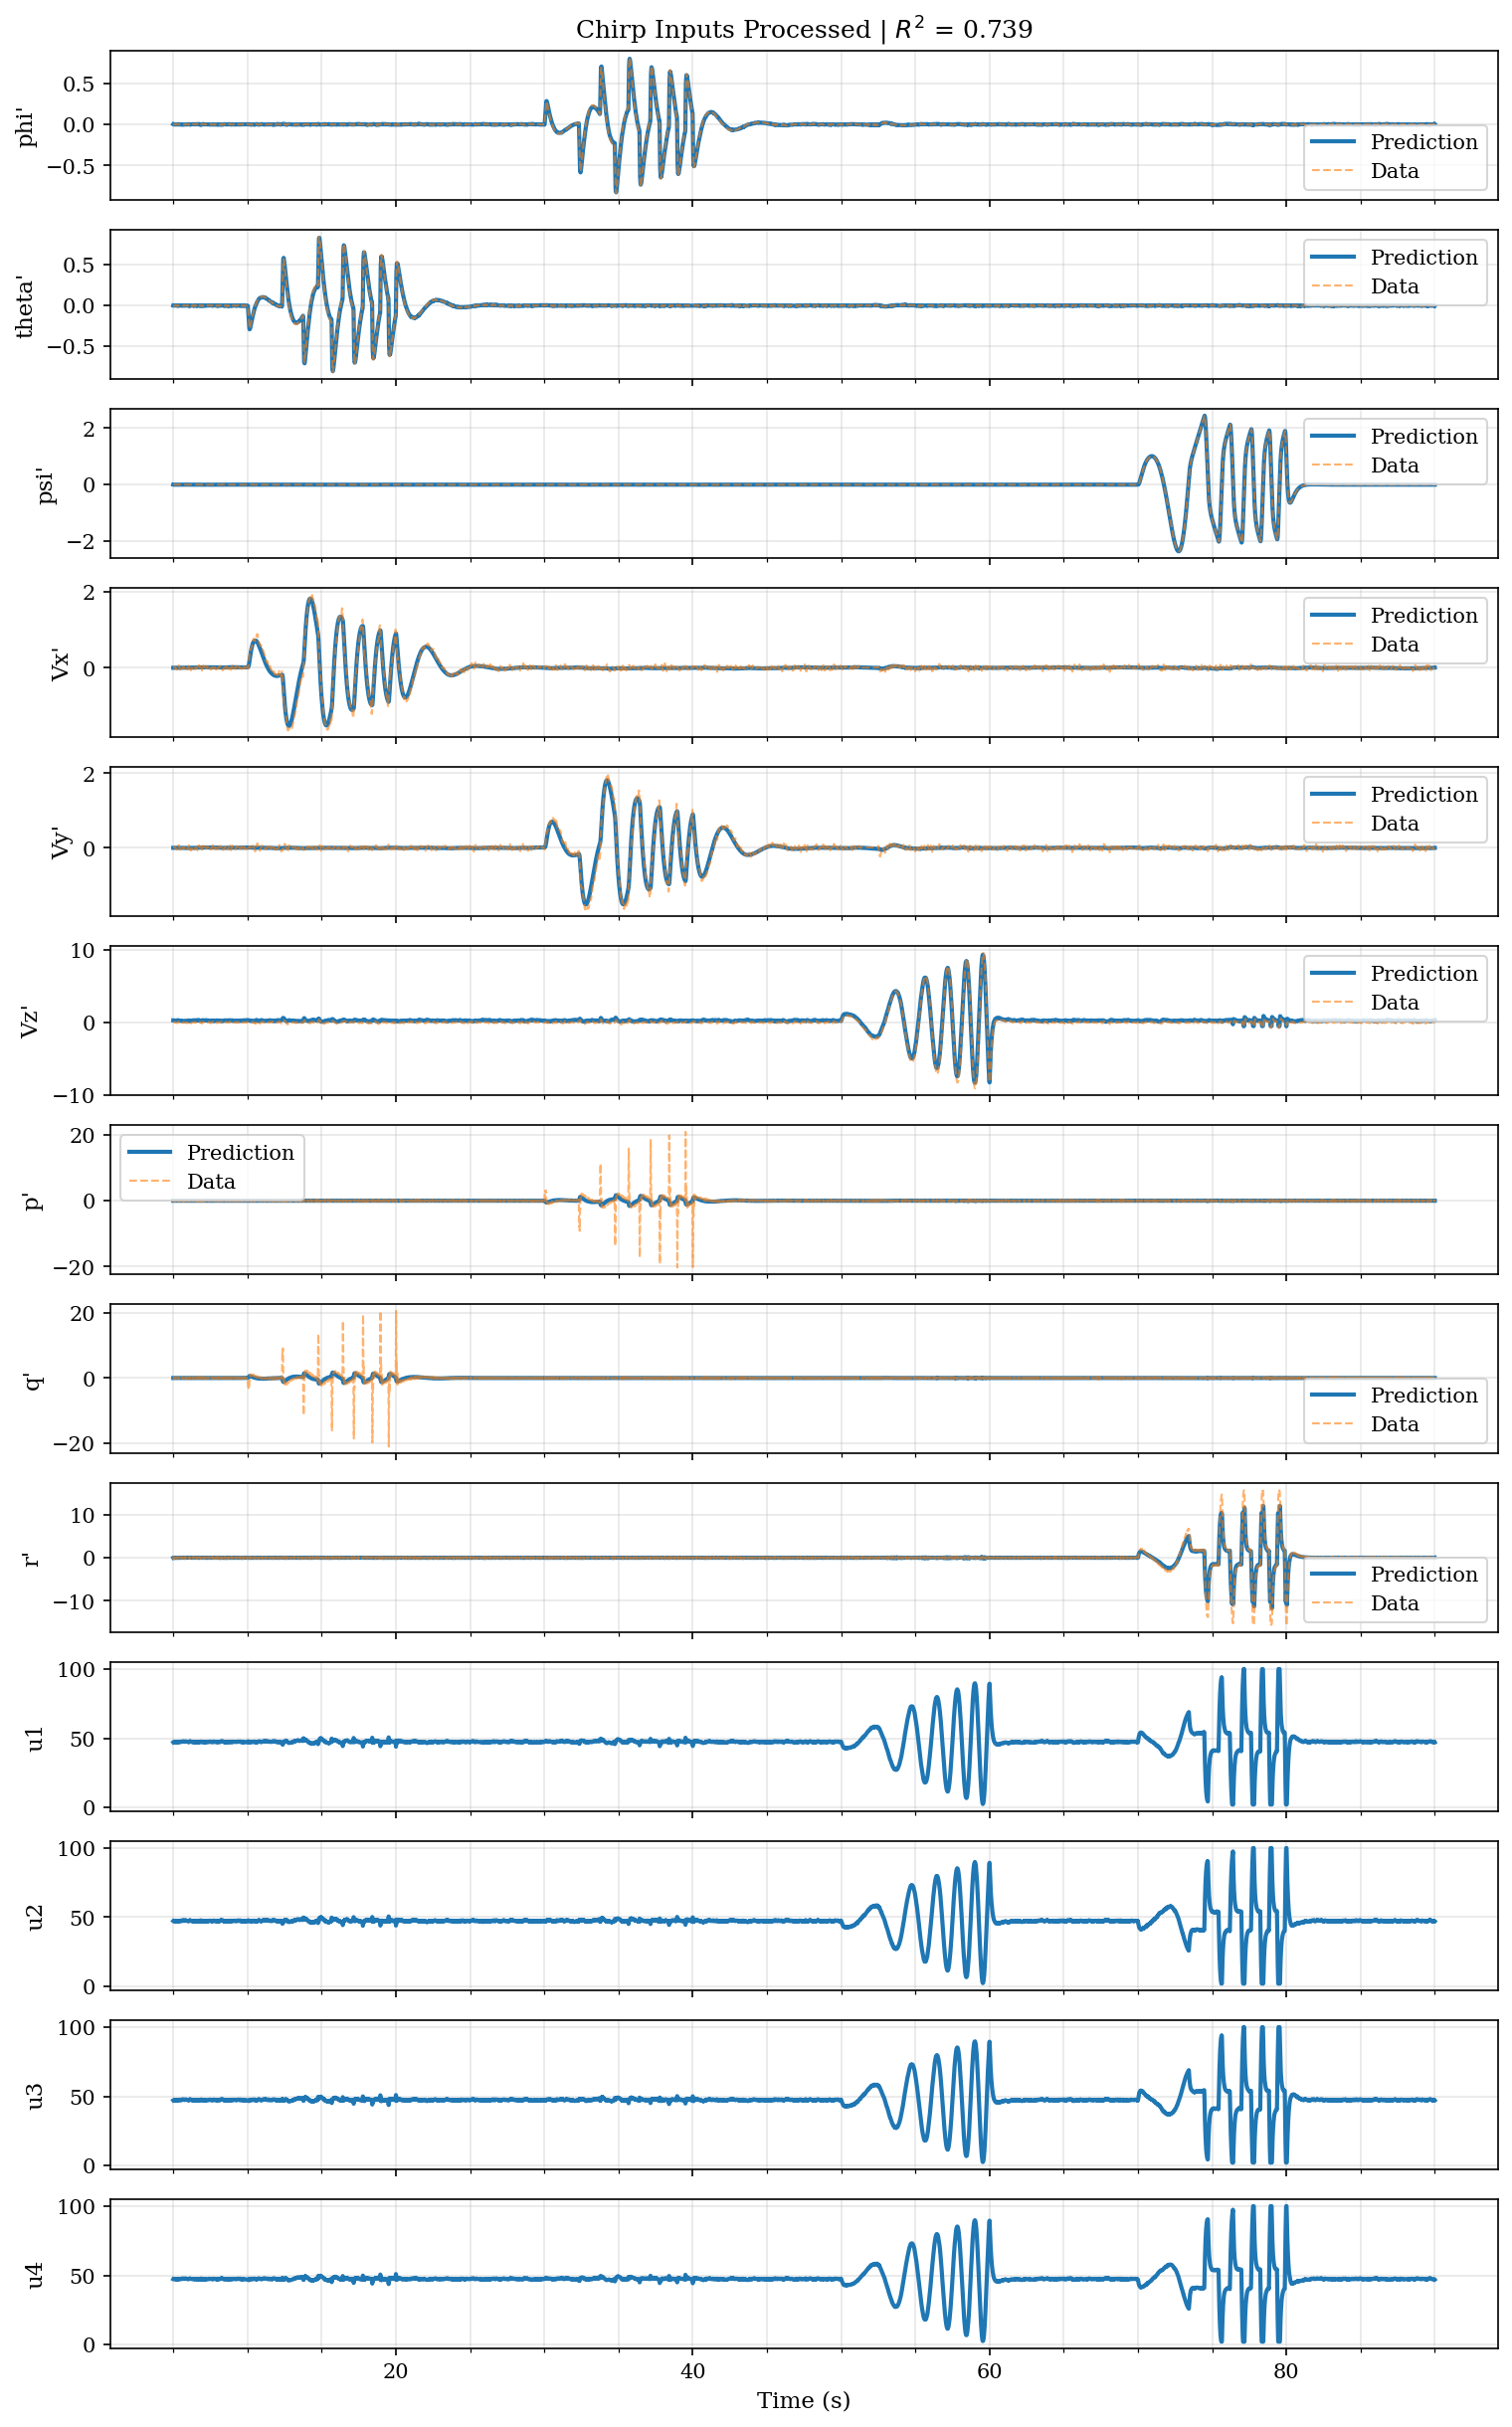

In [74]:
for log_idx in range(len(training_logs)):

    xdot_predict = model.predict(x_train[log_idx], u_train[log_idx])
    xdot_train = ps.FiniteDifference(order=4)._differentiate(
        x_train[log_idx], t_train[log_idx]
    )

    _, axs = plt.subplots(9+4, 1, sharex=True, figsize=(12,20))

    for idx in range(9):
        axs[idx].plot(
            t_train[log_idx], xdot_predict[:, idx], label='Prediction'
        )
        axs[idx].plot(
            t_train[log_idx], xdot_train[:, idx], '--', label='Data',
            linewidth=1, alpha=0.6
        )
        axs[idx].set_ylabel(f"{feature_names[idx]}'")
        axs[idx].legend()

    for idx in range(4):
        axs[idx+9].plot(t_train[log_idx], u_train[log_idx][:, idx])
        axs[idx+9].set_ylabel(f'{input_names[idx]}')

    r2score = model.score(
        x_train[log_idx], t_train[log_idx], u=u_train[log_idx]
    )

    axs[0].set_title(
        f'{log_names[training_logs[log_idx]]}'.removesuffix('.npz')
        + f' | $R^2$ = {r2score:.3f}'
    )
    axs[-1].set_xlabel('Time (s)')

Despite the high noise levels from the data, we can see that due to the regularized regression employed, SINDy did not overfit to the noise, but captures just the true dynamics.

> Despite the prediction matching well with the prediction, the $R^2$ score is quite low in most cases. $R^2$ also evaluates the model's ability to match the data's variance, but a good SINDy model should not overfit to noise. What other metrics can we use here? And what application is $R^2$ better suited for?


## Assessing Accuracy using Validation Data

Let us validate the model with the validation data.

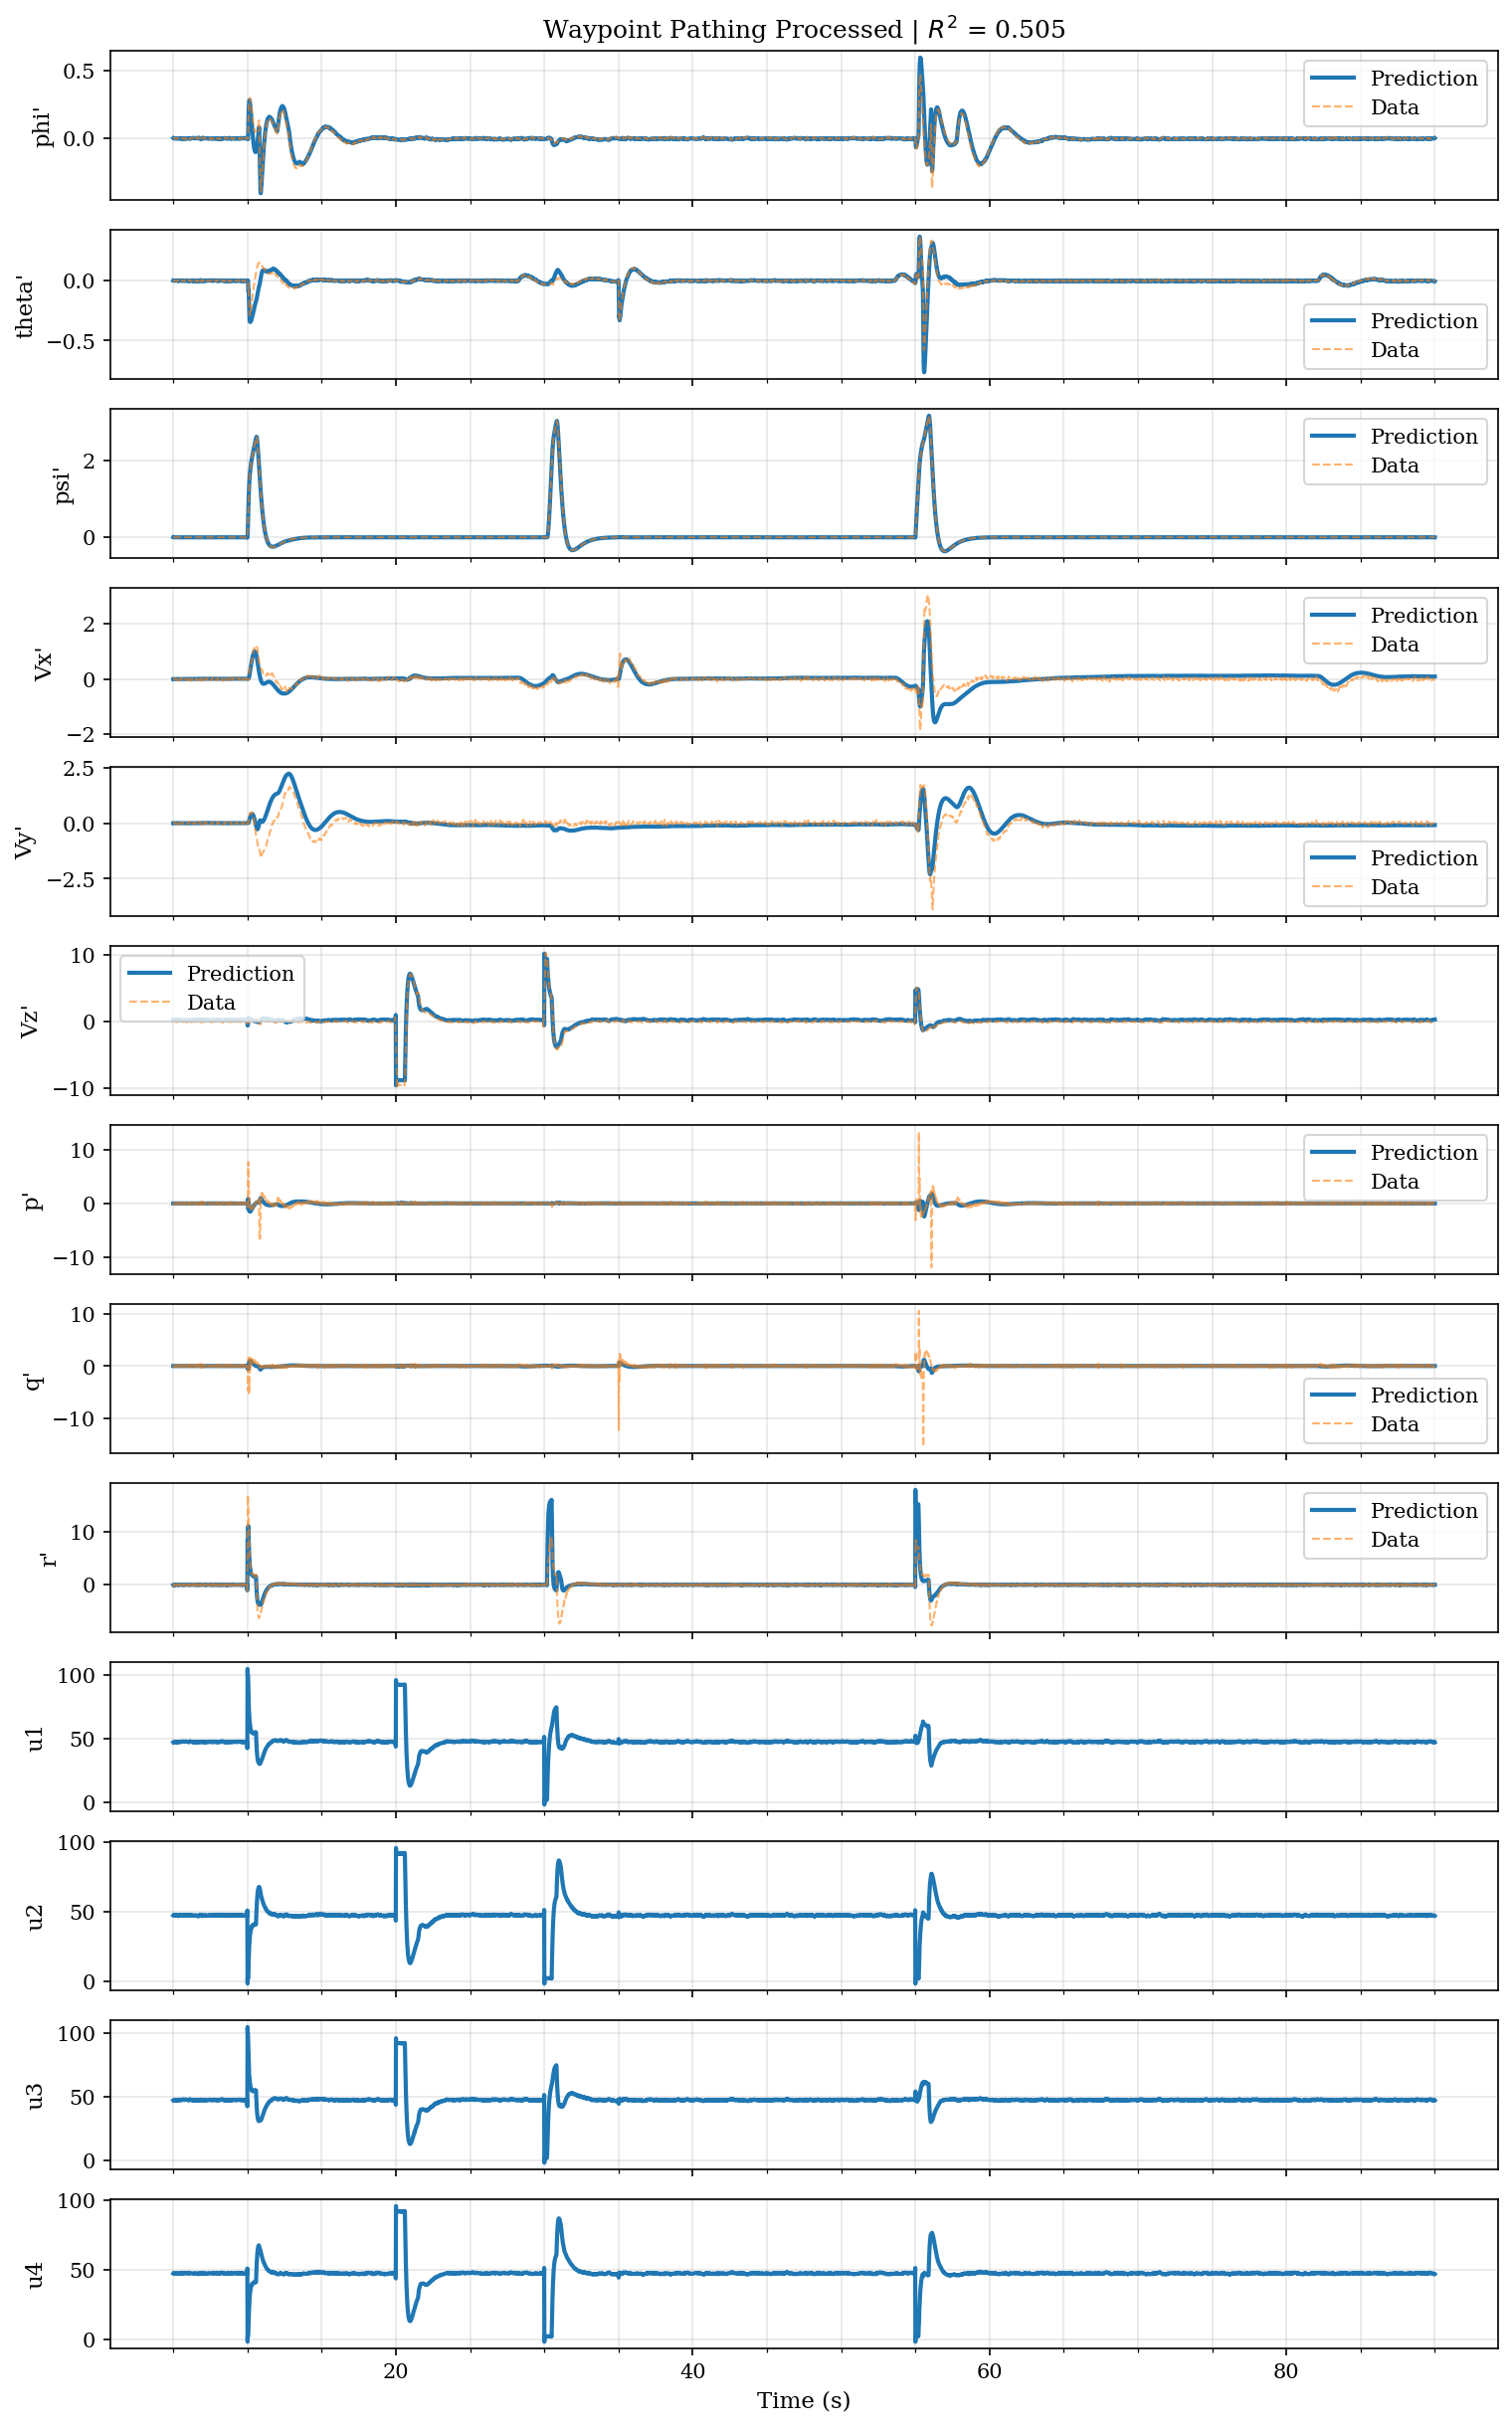

In [75]:
for log_idx in range(len(validation_logs)):

    xdot_predict = model.predict(x_valid[log_idx], u_valid[log_idx])
    xdot_valid = ps.FiniteDifference(order=4)._differentiate(
        x_valid[log_idx], t_valid[log_idx]
    )

    _, axs = plt.subplots(9+4, 1, sharex=True, figsize=(12,20))

    for idx in range(9):
        axs[idx].plot(
            t_valid[log_idx], xdot_predict[:, idx], label='Prediction'
        )
        axs[idx].plot(
            t_valid[log_idx], xdot_valid[:, idx], '--', label='Data',
            linewidth=1, alpha=0.6
        )
        axs[idx].set_ylabel(f"{feature_names[idx]}'")
        axs[idx].legend()

    for idx in range(4):
        axs[idx+9].plot(t_valid[log_idx], u_valid[log_idx][:, idx])
        axs[idx+9].set_ylabel(f'{input_names[idx]}')

    r2score = model.score(
        x_valid[log_idx], t_valid[log_idx], u=u_valid[log_idx]
    )

    axs[0].set_title(
        f'{log_names[validation_logs[log_idx]]}'.removesuffix('.npz')
        + f' | $R^2$ = {r2score:.3f}'
    )
    axs[-1].set_xlabel('Time (s)')

As shown above, the learned SINDy model is generally able to capture the vehicle dynamics relatively accurately. Subsequently, we may use the learned model to develop control policies using methods such as SINDy-MPC. It also allows us to analyze the stability of the system linearized at different equilibrium points if a model was not available before.

> Now that we have a SINDy training pipeline, try playing around with the training dataset. What happens if we only use the waypoint flight as training data? Can SINDy still learn all key dynamics? What if we apply more aggressive data smoothing filters on high frequency states such as angular rates?

In this example, we have demonstrated several methods of baking in prior knowledge in the equation learning process:
1. Meticulous construction of custom candidate function libraries.
2. Baking in both known coefficients and sparsity.